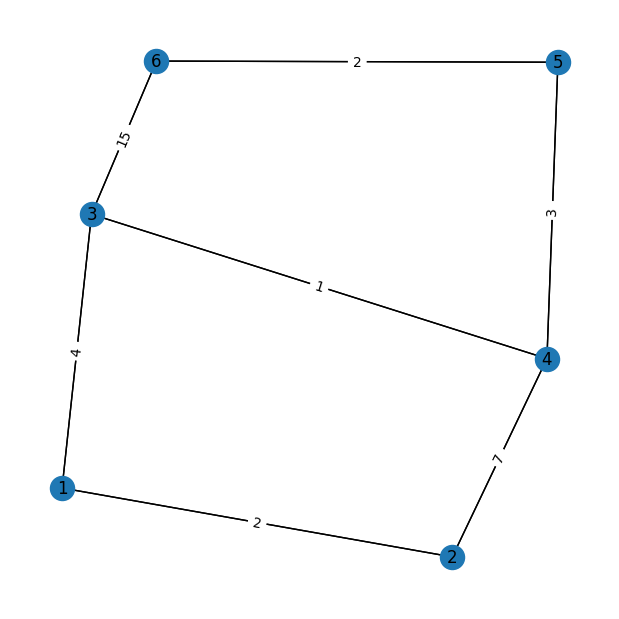

In [2]:
from matplotlib import pyplot as plt
import numpy as np
import networkx as nx


mat = np.array([
    [0, 2, 4, 0, 0, 0],
    [2, 0, 0, 7, 0, 0],
    [4, 0, 0, 1, 0, 15],
    [0, 7, 1, 0, 3, 0],
    [0, 0, 0, 3, 0, 2],
    [0, 0, 15, 0, 2, 0]
])

plt.figure(figsize=(6, 6))

n = len(mat)
labels = {i: i + 1 for i in range(n)}
edge_labels = {(i, j): f'{mat[i][j]}' for i in range(n) for j in range(n) if mat[i][j] != 0}

G = nx.from_numpy_array(mat, create_using=nx.DiGraph)
pos = nx.spring_layout(G)
nx.draw(G, pos, labels=labels, arrows=False)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.show()

In [ ]:
from math import inf as INF

def dijkstra(graph: np.array, v=0):
    def arg_min(dist, visited):
        amin = -1
        m = INF
        for i, t in enumerate(dist):
            if t < m and i not in visited:
                m = t
                amin = i

        return amin


    n: int = len(graph)
    dist = np.array([float('inf')] * n)
    dist[v] = 0
    visited = {v}

    while v != -1:
        for j, dw in enumerate(graph[v]):
            if j not in visited:
                w = dist[v] + dw
                if w < dist[j]:
                    dist[j] = w

        v = arg_min(dist, visited)
        if v >= 0:
            visited.add(v)
    
    return dist

mat = np.array([
    [0  , 2  , 4  , INF, INF, INF],
    [2  , 0  , INF, 7  , INF, INF],
    [4  , INF, 0  , 1  , INF, 15 ],
    [INF, 7  , 1  , 0  , 3  , INF],
    [INF, INF, INF, 3  , 0  , 2  ],
    [INF, INF, 15 , INF, 2  , 0  ]
])
print(dijkstra(mat))

[ 0.  2.  4.  5.  8. 10.]


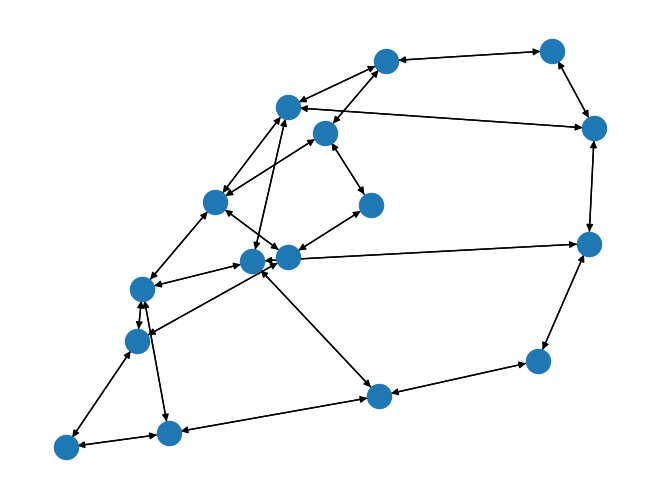

In [4]:
def create_grid_graph(m: int):
    n = m ** 2
    graph = np.array([[0] * n for _ in range(n)])
    
    for v in range(n):
        r, c = v // m, v % m

        if c < (m - 1):
            graph[v][v + 1] = graph[v + 1][v] = np.random.randint(1, 10)
        if r < (m - 1):
            graph[v][v + m] = graph[v + m][v] = np.random.randint(1, 10)
    
    return graph

nx.draw(nx.DiGraph(create_grid_graph(4)))

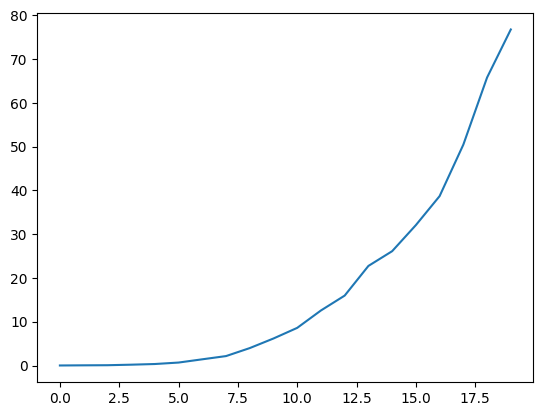

In [5]:
from time import time
from matplotlib import pyplot as plt

def measure_time():
    times = []
    for i in range(0, 20):
        mat = create_grid_graph(i + 1)
        start = time()
        for _ in range(1000):
            dijkstra(mat, 0)
        end = time() - start
        times.append(end)
    plt.plot(times)

measure_time()